# **[IA02] Data Complexity and Meta-Learning on Obesity Dataset**

##### Francisco Campos (FEUP/FCUP, M.IA)

## **Introduction and Prerequisites**

In this tutorial, we will analyse the [Obesity Levels](https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels) dataset. The purpose of this tutorial is to analyse the data complexity of the dataset, to understand how meta-features affect the performance of **classification algorithms with different learning paradigms**. For that, we will use three libraries: `pyhard`, `problexity`, and `pymfe`:
- `pyhard`  provides a set of data complexity Instance Hardness (IH) measures, which is useful to understand the complexity or difficulty of individual instances.
- `problexity`  provides a set of data complexity measures, being deeply related to the concept of Meta-Learning.
- `pymfe` provides a set of meta-features that can be used to understand the complexity of the dataset.

### **Prerequisites**

To reproduce the following tutorial, we recommend the following steps:

- Create a new conda environment with Python 3.9 (most of the libraries are compatible with Python 3.9)
- Activate the environment
- Install `pyhard` using `pip`
- Downgrade `numpy` version to `1.23.3` (some conflicts have been reported for newer `numpy` versions)
- Install `problexity` and `pymfe` using `pip`
- Install `jupyter` and `ipykernel` in case you'd like to work with jupyter notebooks

```bash
conda create -n pyhard-tutorial python=3.9
conda activate pyhard-tutorial
pip install pyhard
pip install -U numpy==1.23.3
pip install problexity
pip install -U pymfe
pip install jupyter ipykernel
```

In [27]:
import warnings
warnings.filterwarnings('ignore')

## **Initial Data Preparation**

This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

- **Gender**: Feature, Categorical, "Gender"
- **Age** : Feature, Continuous, "Age"
- **Height**: Feature, Continuous
- **Weight**: Feature Continuous
- **family_history_with_overweight**: Feature, Binary, " Has a family member suffered or suffers from overweight? "
- **FAVC**: Feature, Binary, " Do you eat high caloric food frequently? "
- **FCVC**: Feature, Integer, " Do you usually eat vegetables in your meals? "
- **NCP**: Feature, Continuous, " How many main meals do you have daily? "
- **CAEC**: Feature, Categorical, " Do you eat any food between meals? "
- **SMOKE**: Feature, Binary, " Do you smoke? "
- **CH2O**: Feature, Continuous, " How much water do you drink daily? "
- **SCC**: Feature, Binary, " Do you monitor the calories you eat daily? "
- **FAF**: Feature, Continuous, " How often do you have physical activity? "
- **TUE**: Feature, Integer, " How much time do you use technological devices such as cell phone, videogames, television, computer and others? "
- **CALC**: Feature, Categorical, " How often do you drink alcohol? "
- **MTRANS**: Feature, Categorical, " Which transportation do you usually use? "
- **NObeyesdad**: Target, Categorical, "Obesity level"

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("obesity.csv")

### Data Cleaning

In [29]:
df

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.000000,Female,1.620000,64.000000,no,no,2.0,3.0,no,no,2.000000,yes,0.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
1,21.000000,Female,1.520000,56.000000,Sometimes,no,3.0,3.0,yes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,23.000000,Male,1.800000,77.000000,Frequently,no,2.0,3.0,no,no,2.000000,yes,2.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
3,27.000000,Male,1.800000,87.000000,Frequently,no,3.0,3.0,no,no,2.000000,no,2.000000,0.000000,Sometimes,Walking,Overweight_Level_I
4,22.000000,Male,1.780000,89.800000,Sometimes,no,2.0,1.0,no,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,Female,1.710730,131.408528,Sometimes,yes,3.0,3.0,no,no,1.728139,yes,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.982942,Female,1.748584,133.742943,Sometimes,yes,3.0,3.0,no,no,2.005130,yes,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524036,Female,1.752206,133.689352,Sometimes,yes,3.0,3.0,no,no,2.054193,yes,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.361936,Female,1.739450,133.346641,Sometimes,yes,3.0,3.0,no,no,2.852339,yes,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [30]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [31]:
print("Dataset Size: ", df.shape)
print("===Target Distribution:===", df["NObeyesdad"].value_counts(), sep='\n')
print("==========================")
print("Missing Values: ", df.isna().sum().sum())

Dataset Size:  (2111, 17)
===Target Distribution:===
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: NObeyesdad, dtype: int64
Missing Values:  0


### Feature Selection

As it is possible to see, this dataset has a lot o features, so we need to select the most relevant ones. 

After using the functions above to better understand our data, we notice that the variables `Gender`, `family_history_with_overweight`, `FAVC`, `CAEC`, `SMOKE`, `SCC`, `CALC`, and `MTRANS` are categorical. We will later convert the useful variables to our dataset into numerical values.

In [32]:
cat_vars = ["Gender", "CALC", "FAVC", "SCC", "SMOKE", "family_history_with_overweight", "MTRANS", "CAEC"]
print("=========================")
for var in cat_vars:
    print(var,":\n", df[var].value_counts(), sep="")
    print("=========================")


Gender:
Male      1068
Female    1043
Name: Gender, dtype: int64
CALC:
Sometimes     1401
no             639
Frequently      70
Always           1
Name: CALC, dtype: int64
FAVC:
yes    1866
no      245
Name: FAVC, dtype: int64
SCC:
no     2015
yes      96
Name: SCC, dtype: int64
SMOKE:
no     2067
yes      44
Name: SMOKE, dtype: int64
family_history_with_overweight:
yes    1726
no      385
Name: family_history_with_overweight, dtype: int64
MTRANS:
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: MTRANS, dtype: int64
CAEC:
Sometimes     1765
Frequently     242
Always          53
no              51
Name: CAEC, dtype: int64


We will now drop the following categorical columns:
- `SCC`: Since the question "Do you monitor the calories you eat daily?" is not relevant to the obesity level.
- `SMOKE`: Since the number of smokers is very low, we will drop this column (they don't have a significant impact on the obesity level).
- `MTRANS`: The main transportation could have been an interesing feature if the number of people who walk or use a bicycle was significant. However, the number of people who use these transportation methods is very low, so we will drop this column.
- `CAEC`: This feature would have been more useful if it had the number of meals people usually have. Since we already have other nutricional measures (like FAVC, FCVC and NCP), we will drop this column.

For the remaining ones, we'll do Label Encoding

In [33]:
df.drop(["SCC", "SMOKE", "MTRANS", "CAEC"], axis=1, inplace=True)

df['Female'] = df['Gender'].apply(lambda x: 1 if x == 'Female' else 0)
df = df.drop(['Gender'], axis=1)

df['FAVC'] = (df['FAVC'] == 'yes').astype(int)

df['family_history_with_overweight'] = (df['family_history_with_overweight'] == 'yes').astype(int)

mapping = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df['CALC'] = df['CALC'].map(mapping)

df

,Age,Height,Weight,CALC,FAVC,FCVC,NCP,CH2O,family_history_with_overweight,FAF,TUE,NObeyesdad,Female
0,21.000000,1.620000,64.000000,0,0,2.0,3.0,2.000000,1,0.000000,1.000000,Normal_Weight,1
1,21.000000,1.520000,56.000000,1,0,3.0,3.0,3.000000,1,3.000000,0.000000,Normal_Weight,1
2,23.000000,1.800000,77.000000,2,0,2.0,3.0,2.000000,1,2.000000,1.000000,Normal_Weight,0
3,27.000000,1.800000,87.000000,2,0,3.0,3.0,2.000000,0,2.000000,0.000000,Overweight_Level_I,0
4,22.000000,1.780000,89.800000,1,0,2.0,1.0,2.000000,0,0.000000,0.000000,Overweight_Level_II,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,1.710730,131.408528,1,1,3.0,3.0,1.728139,1,1.676269,0.906247,Obesity_Type_III,1
2107,21.982942,1.748584,133.742943,1,1,3.0,3.0,2.005130,1,1.341390,0.599270,Obesity_Type_III,1
2108,22.524036,1.752206,133.689352,1,1,3.0,3.0,2.054193,1,1.414209,0.646288,Obesity_Type_III,1
2109,24.361936,1.739450,133.346641,1,1,3.0,3.0,2.852339,1,1.139107,0.586035,Obesity_Type_III,1


### Feature Engineering

When talking about obesity, one of the main features that helps with identifying the obesity level is the Body Mass Index (BMI). The BMI is calculated by dividing the weight of the individual by the square of the height:

$$BMI = \frac{weight}{height^2}$$

However, we should be careful with the BMI, as it is not a perfect measure of obesity. For example, it does not take into account the muscle mass of the individual, which can lead to misclassification of the obesity level.

Since the dataset does not contain the BMI, we will calculate it using the `Weight` and `Height` features.

In [34]:
df["BMI"] = df["Weight"]/(df["Height"]**2)

df.drop(["Weight", "Height"], axis=1, inplace=True)

### Target Variable Merge

As you can see, the target variable has 7 classes. We will merge these classes into 4 classes: `Underweight`, `Normal`, and `Overweight`, `Obese`. This means we will only consider the umbrella terms for the obesity levels. So for example, `Obesity Type I`, `Obesity Type II` will be merged into `Obese` (we'll just keep the `Obesity_Type_III`, to see if the variables differ for the most extreme cases). The same will apply for the Overweight levels.

In [35]:
# Define the mapping for merging classes
class_mapping = {
    'Insufficient_Weight': 'Underweight',
    'Normal_Weight': 'Normal',
    'Overweight_Level_I': 'Overweight',
    'Overweight_Level_II': 'Overweight',
    'Obesity_Type_I': 'Obesity',
    'Obesity_Type_II': 'Obesity',
    'Obesity_Type_III': 'Obesity_Type_III'
}

# Apply the mapping to the target variable
df['NObeyesdad'] = df['NObeyesdad'].map(class_mapping)

### Ploting

Now, we will plot the distribution of the target variable `NObeyesdad` to understand the distribution of the classes. For that, we will see how the BMI distribution is related to the obesity level, paired up with other features of the dataset.

In [36]:
hue_order = ['Underweight', 'Normal', 'Overweight', 'Obesity', 'Obesity_Type_III']

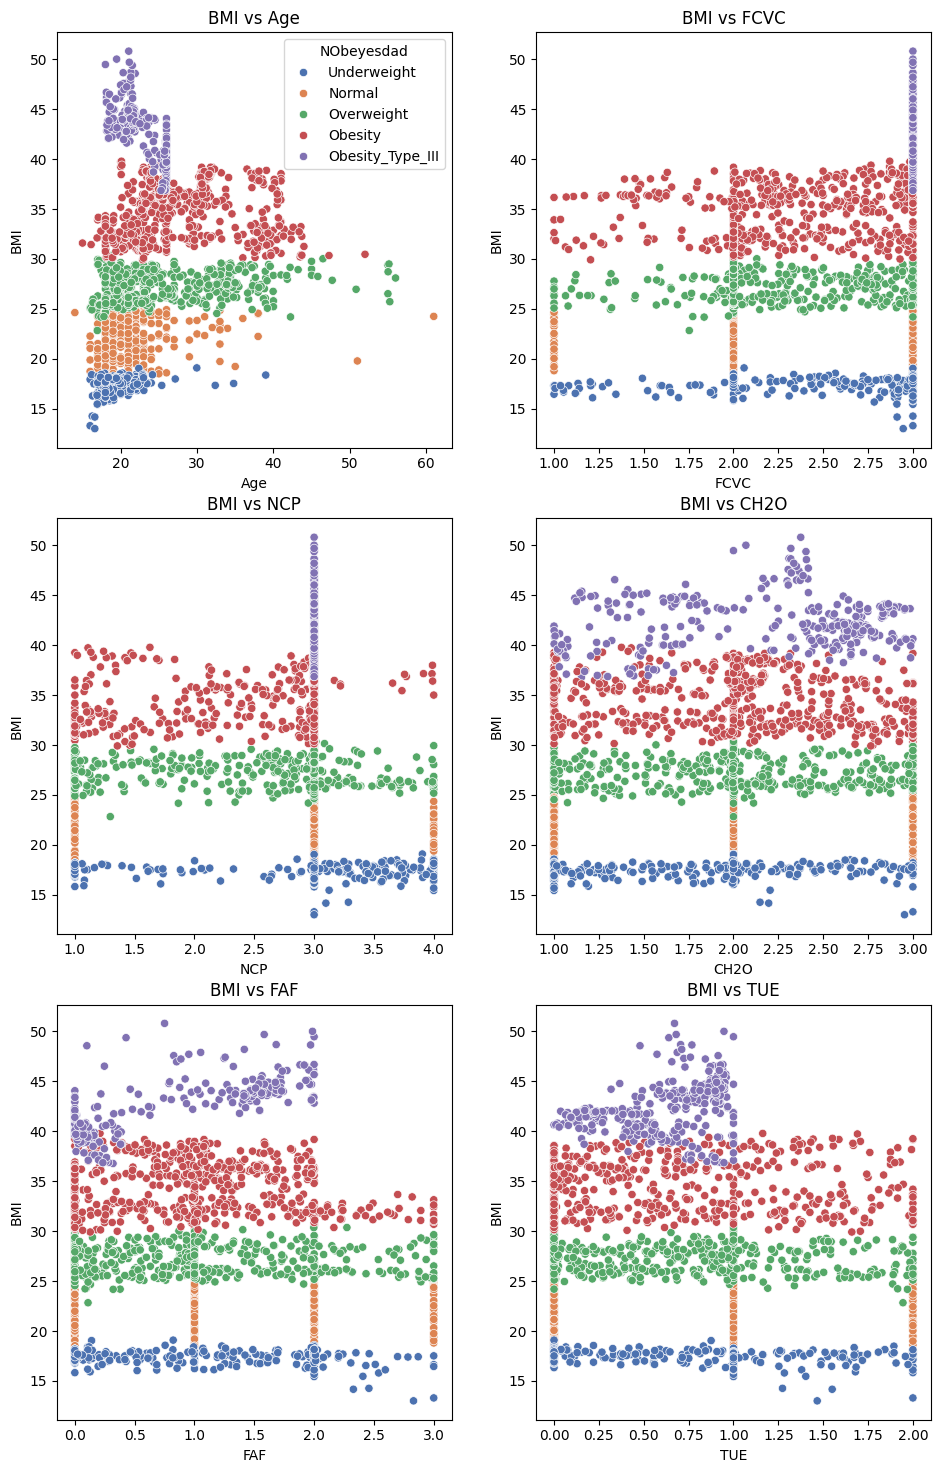

In [37]:
cont_cols= ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF','TUE']

# Define number of rows and columns for the subplots grid
num_cols = 2
num_rows = (len(cont_cols) + num_cols - 1) // num_cols  

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
fig.tight_layout(pad=3)

# Flatten axes array for easier indexing if it's a 2D array
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    sns.scatterplot(data=df, x=col, y="BMI", hue="NObeyesdad", palette="deep", ax=axes[i], legend=(i == 0), hue_order=hue_order)
    axes[i].set_title(f"BMI vs {col}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.show()

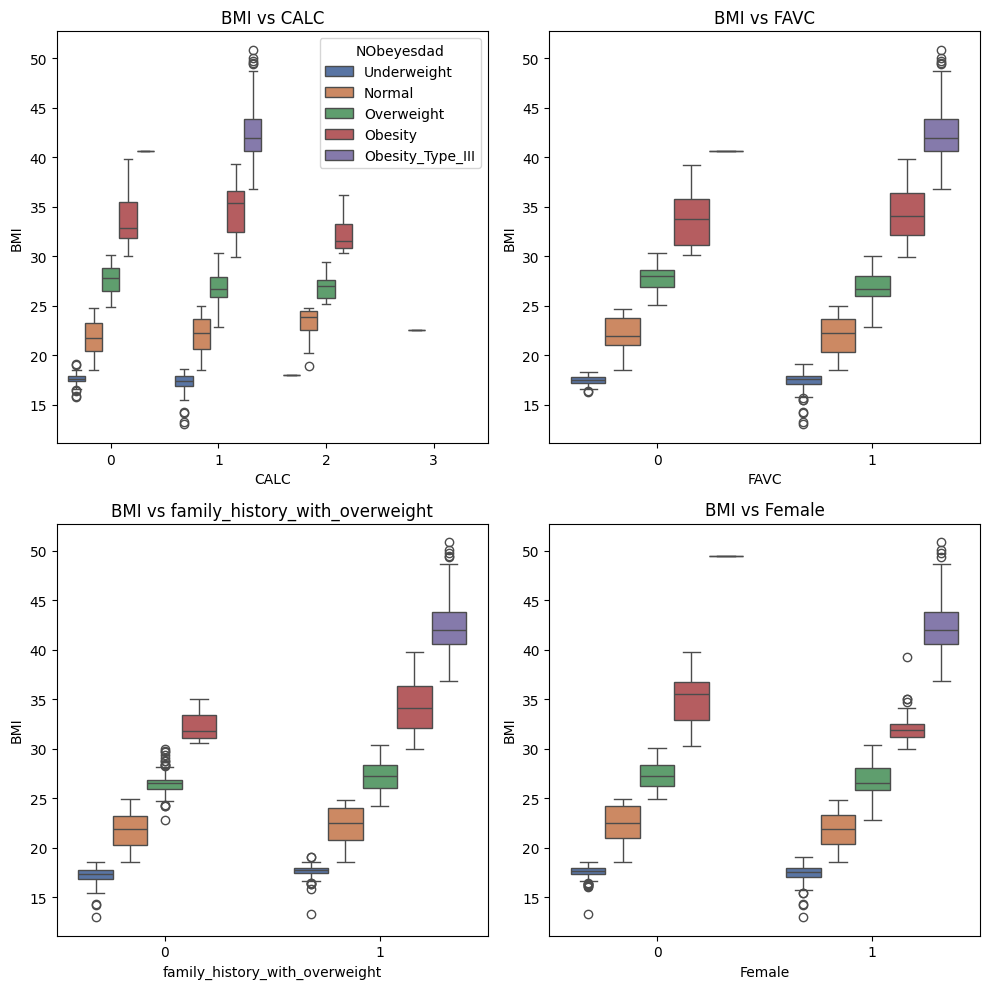

In [38]:
disc_cols = ['CALC', 'FAVC', 'family_history_with_overweight','Female']

# Define number of rows and columns for the subplots grid
num_cols = 2
num_rows = (len(disc_cols) + num_cols - 1) // num_cols  

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(disc_cols):
    sns.boxplot(data=df, x=col, y="BMI", hue="NObeyesdad", palette="deep", ax=axes[i], legend=(i == 0), hue_order=hue_order)
    axes[i].set_title(f"BMI vs {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


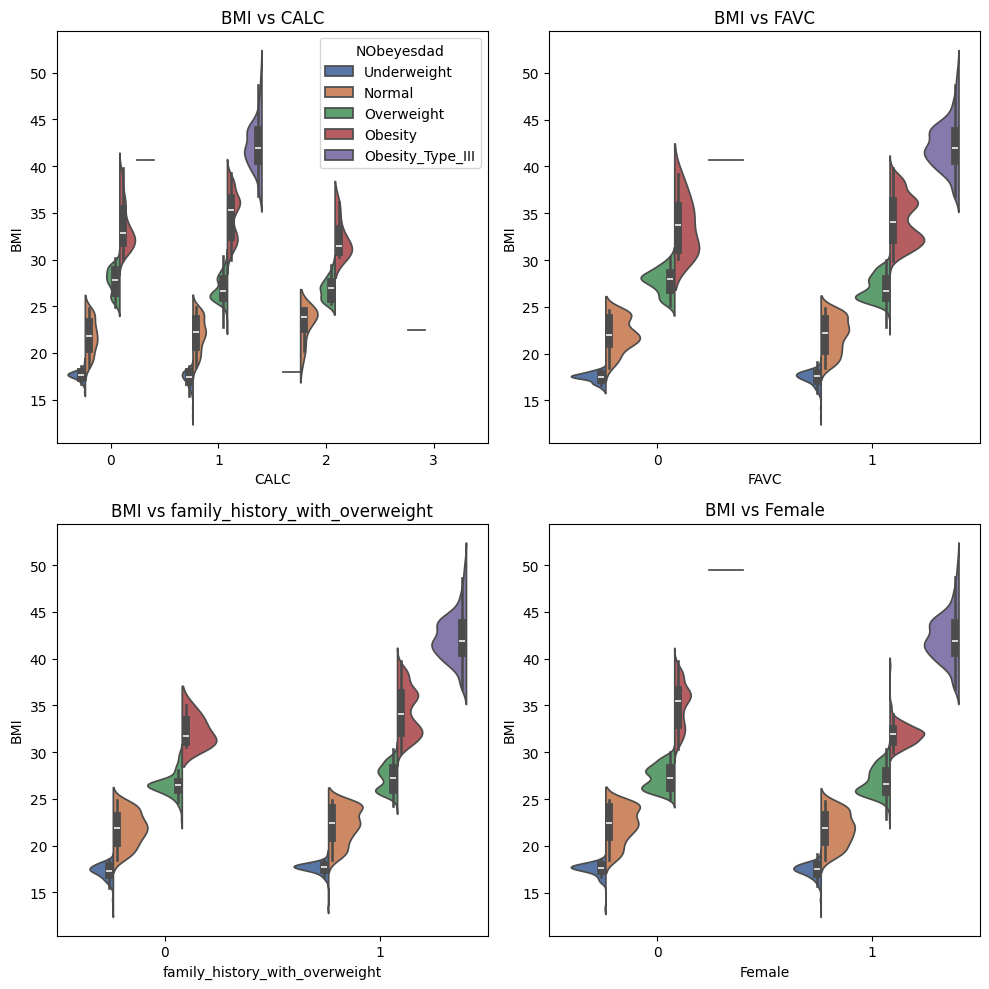

In [39]:
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
fig.tight_layout(pad=3)

# Flatten axes array for easier indexing if it's a 2D array
axes = axes.flatten()

for i, col in enumerate(disc_cols):
    sns.violinplot(data=df, x=col, y="BMI", hue="NObeyesdad", split=True, palette="deep", ax=axes[i], legend=(i == 0), hue_order=hue_order)
    axes[i].set_title(f"BMI vs {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

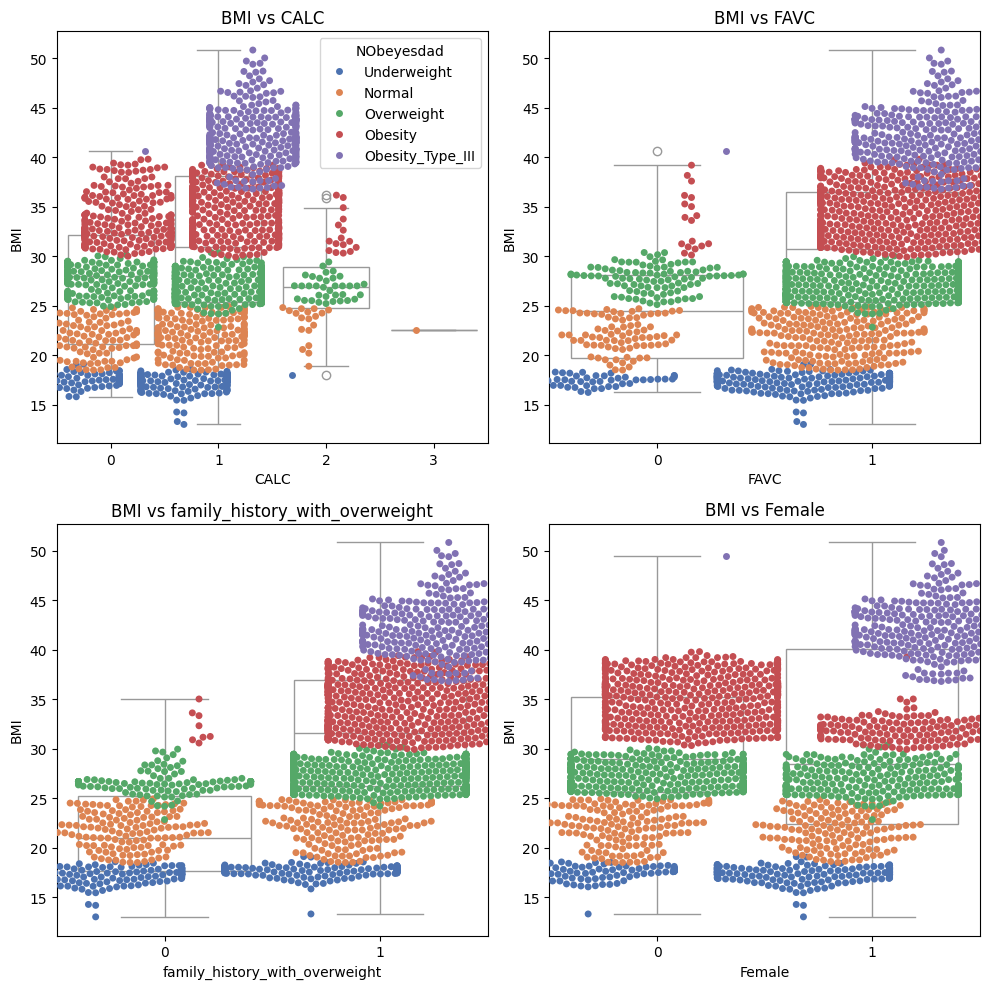

In [40]:
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
fig.tight_layout(pad=3)

# Flatten axes array for easier indexing if it's a 2D array
axes = axes.flatten()

for i, col in enumerate(disc_cols):
    sns.boxplot(data=df, x=col, y="BMI", color="white", ax=axes[i])
    sns.swarmplot(data=df, x=col, y="BMI", hue="NObeyesdad", palette="deep", ax=axes[i], legend=(i == 0), dodge=True, hue_order=hue_order)
    axes[i].set_title(f"BMI vs {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

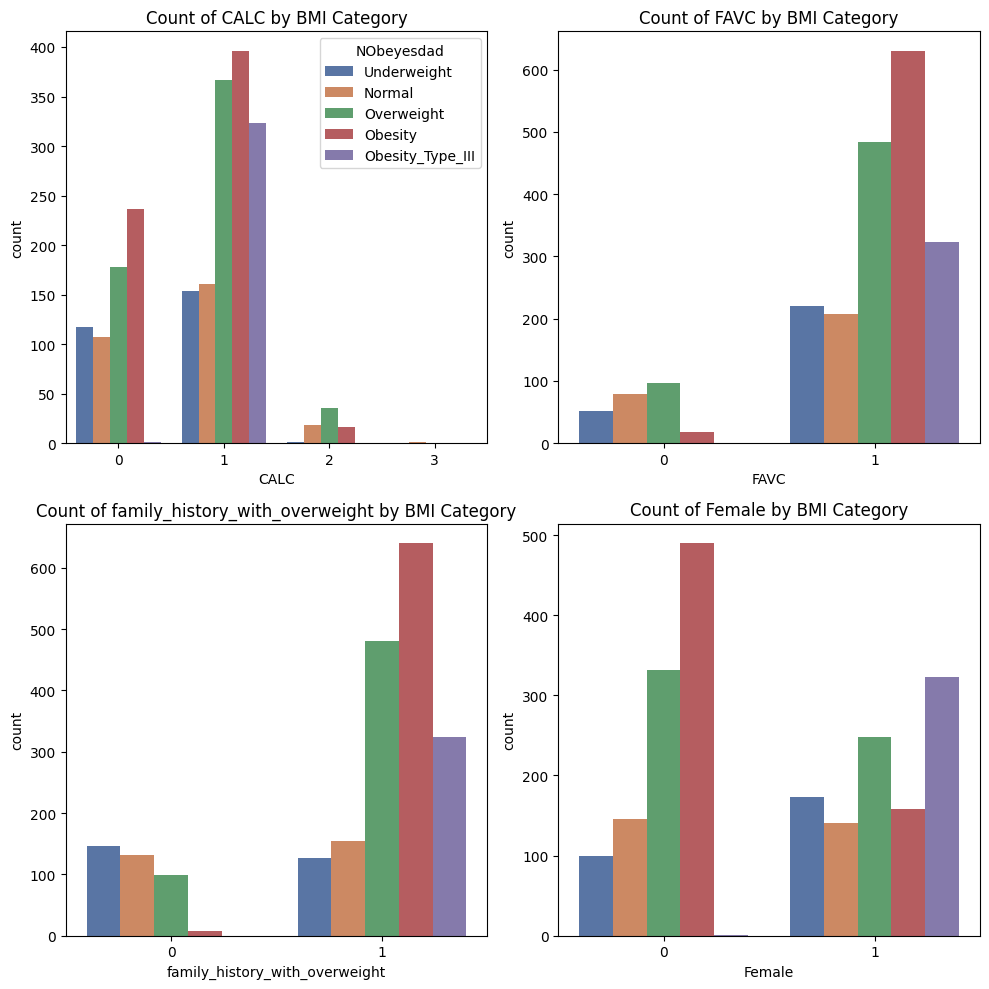

In [41]:
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
fig.tight_layout(pad=3)

# Flatten axes array for easier indexing if it's a 2D array
axes = axes.flatten()

for i, col in enumerate(disc_cols):
    sns.countplot(data=df, x=col, hue="NObeyesdad", palette="deep", ax=axes[i], legend=(i == 0), hue_order=hue_order)
    axes[i].set_title(f"Count of {col} by BMI Category")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

As a final step, we will put the target variable in the last column of the dataset. We will also encode the target variable to numerical values.

In [42]:
columns = [col for col in df.columns if col != 'NObeyesdad'] + ['NObeyesdad']
df = df[columns]

# Define the mapping for merging classes
class_mapping = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obesity': 3,
    'Obesity_Type_III': 4
}

# Apply the mapping to the target variable
df['NObeyesdad'] = df['NObeyesdad'].map(class_mapping)

df

,Age,CALC,FAVC,FCVC,NCP,CH2O,family_history_with_overweight,FAF,TUE,Female,BMI,NObeyesdad
0,21.000000,0,0,2.0,3.0,2.000000,1,0.000000,1.000000,1,24.386526,1
1,21.000000,1,0,3.0,3.0,3.000000,1,3.000000,0.000000,1,24.238227,1
2,23.000000,2,0,2.0,3.0,2.000000,1,2.000000,1.000000,0,23.765432,1
3,27.000000,2,0,3.0,3.0,2.000000,0,2.000000,0.000000,0,26.851852,2
4,22.000000,1,0,2.0,1.0,2.000000,0,0.000000,0.000000,0,28.342381,2
...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,1,1,3.0,3.0,1.728139,1,1.676269,0.906247,1,44.901475,4
2107,21.982942,1,1,3.0,3.0,2.005130,1,1.341390,0.599270,1,43.741923,4
2108,22.524036,1,1,3.0,3.0,2.054193,1,1.414209,0.646288,1,43.543817,4
2109,24.361936,1,1,3.0,3.0,2.852339,1,1.139107,0.586035,1,44.071535,4


## **Data Complexity Analysis with [problexity](https://problexity.readthedocs.io/en/latest/index.html)**

In [43]:
import problexity as px

# Initialize ComplexityCalculator with default parametrization
cc = px.ComplexityCalculator()

In [44]:
X = df.iloc[:,:-1].to_numpy() # Features
y = df.iloc[:,-1].to_numpy() # Target

# Fit model with data
cc.fit(X,y)

The table bellow shows the metrics used by `problexity` on the presented dataset, with the respective complexity value, and corresponding starda deviation. The complexity values are normalized between 0 and 1, where 0 means low complexity and 1 means high complexity.

In [45]:
report = cc.report()
cmplxty_measures = report["complexities"]
cmplxty_std = report["complexities_std"]

df_cmplxty_measures = pd.DataFrame(cmplxty_measures, index=[0])
df_cmplxty_std = pd.DataFrame(cmplxty_std, index=[0])

df_cmplxty_report = pd.concat([df_cmplxty_measures.T, df_cmplxty_std.T], axis=1)
df_cmplxty_report.columns = ['Complexity', 'Std']
df_cmplxty_report

,Complexity,Std
f1,0.088,0.065
f1v,0.032,0.028
f2,0.014,0.030
f3,0.036,0.060
f4,0.002,0.005
l1,0.007,0.012
l2,0.007,0.011
l3,0.002,0.004
n1,0.005,0.008
n2,0.378,0.110


This is the arithmetic mean of the following metrics:

In [46]:
cc.score()

0.1733733865627437

Finally, let's present these results in a more visually appealing way:

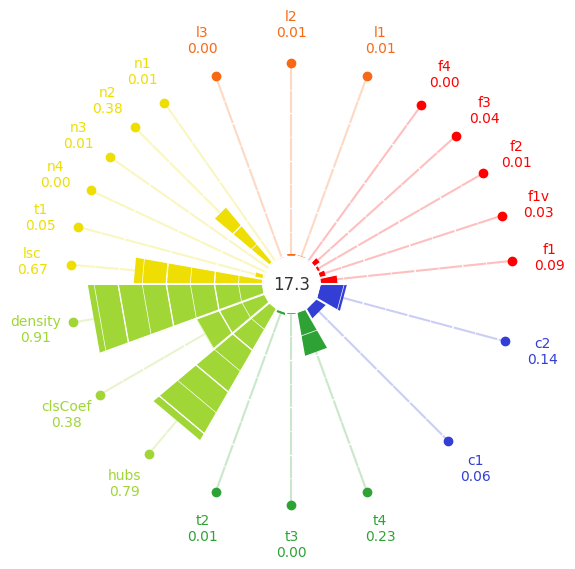

In [47]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,7))
cc.plot(fig, (1,1,1))
plt.savefig("complexity_with_bmi.png")

The graphic is essentially a polar projection showcasing all measures, where each category of measures is grouped into colors:

<ul>
<li><span style="color: red">Red</span> - feature-based measures</li>
<li><span style="color: orange">Orange</span> - linearity measures</li>
<li><span style="color: yellow">Yellow</span> - neighbourhood measures</li>
<li><span style="color: lime">Lime</span> - network measures</li>
<li><span style="color: green">Green</span> - dimensionality measures</li>
<li><span style="color: blue">Blue</span> - class imbalance measures</li>
</ul>

As we can see, the families are evenly distributed in terms of space in the plot, which means families with more metrics (eg. neighbourhood) don't take more space than families with less metrics (eg. class imbalance).

### Main Complexity Insights

As expected this dataset is not highly complex. BMI (even though it is not a perfect measure to generalize obesity) is a good feature to separate the classes, plus the dataset is not highly imbalanced. However, there are some measures that we should analyse:

1. **Density (0.91)**: This measure refers to the average density of the data's connectivity graph. Higher values here suggest that the graph has relatively few connections, meaning the dataset is sparse. This sparsity indicates that instances within the same class might be spread apart, making it challenging for a classifier to learn dense and consistent class boundaries. This makes sense for this dataset, since we have a lot of binary and integer features, which can lead to a sparse dataset.

2. **Hubs (0.79)**: This "hub score" indicates the presence of influential or "central" nodes within the data structure. High values often signify that in areas where classes overlap significantly, the most prominent nodes (data points) are not strongly connected with their nearest neighbors. This scenario is comprehensible in the context of obesity classification, as the difference from one obesity level to another might not be as clear-cut as in other classification tasks. 

3. **LSC (Local Structural Coefficient) (0.67)**: The Local Structural Coefficient measures the clustering behavior of a node’s local neighborhood. A higher LSC implies that many neighbors of a given instance are also connected to each other, creating highly cohesive clusters. In a classification context, this can suggest that certain parts of the feature space have well-defined clusters, which could be useful for identifying substructures within classes. However, this metric may also highlight complex interdependencies within clusters, potentially making it harder for a model to generalize across less cohesive regions.

### Additional Observations and Insights

- **ClsCoef (Classification Coefficient) (0.38)**: This measure is not as high as density or hubs, but it still provides useful insight. It evaluates the separability of classes by assessing the distribution of classes in the input space. Lower values indicate more overlapping classes, which could complicate the learning process for classifiers.
  
- **T-metrics (e.g., T2 at 0.01, T4 at 0.23)**: These "Topological" metrics analyze the topology or shape of data distribution. Lower values for T-metrics may indicate linear separability in some cases, while higher values suggest more complex class boundaries.

- **N-metrics and F-metrics**: These values are relatively low (mostly below 0.1), which could imply that the dataset may not have strong nonlinear separability, at least for certain dimensions. Low values in these metrics could suggest that traditional linear classifiers might perform reasonably well, though the higher density and hub scores suggest there are regions where overlap and separation may still present challenges.

### Without BMI

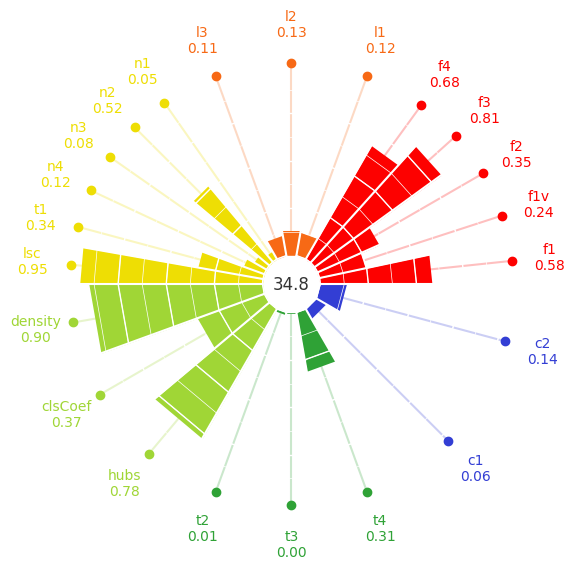

In [48]:
X = df[[col for col in df.columns if col != 'BMI']].iloc[:, :-1].to_numpy() # Features
y = df.iloc[:,-1].to_numpy() # Target

# Fit model with data
cc.fit(X,y)

fig = plt.figure(figsize=(7,7))
cc.plot(fig, (1,1,1))
plt.savefig("complexity_without_bmi.png")

## **Exploring Additional Meta-Features with [pymfe](https://pymfe.readthedocs.io/en/latest/index.html)**

Now we'll be extracting metafeatures from the dataset using `pymfe`. These is the list of all the metafeatures we could get from the dataset, and what they represent:

In [49]:
from pymfe.mfe import MFE
MFE.metafeature_description(sort_by_group=True, sort_by_mtf=True, include_references=True)

+-------------+-------------------+----------------------+---------------------+
|    Group    | Meta-feature name |     Description      |      Reference      |
+=============+===================+======================+=====================+
| clustering  | ch                | Compute the Calinski | [1] T. Calinski, J. |
|             |                   | and Harabasz index.  | Harabasz, A         |
|             |                   |                      | dendrite method for |
|             |                   |                      | cluster analysis,   |
|             |                   |                      | Commun. Stat.       |
|             |                   |                      | Theory Methods 3    |
|             |                   |                      | (1) (1974) 1–27.    |
|             |                   |                      |                     |
+-------------+-------------------+----------------------+---------------------+
| clustering  | int         

In [50]:
X = df.iloc[:,:-1].to_numpy() # Features
y = df.iloc[:,-1].to_numpy() # Target

# Extract complexity measures
mfe = MFE()
mfe.fit(X, y)
ft = mfe.extract()
print("\n".join("{:50} {:30}".format(x, y) for x, y in zip(ft[0], ft[1])))

# Open a file in write mode
with open("mfe_with_bmi.txt", "w") as file:
    # Write each line of the extracted features to the file
    for x, y in zip(ft[0], ft[1]):
        file.write("{:50} {:30}\n".format(x, y))

attr_conc.mean                                                0.04026464328046057
attr_conc.sd                                                 0.044141526943911796
attr_ent.mean                                                   2.180298737338086
attr_ent.sd                                                    1.2028656477607576
attr_to_inst                                                 0.005210800568450971
best_node.mean                                                 0.5788719484932486
best_node.sd                                                0.0027246743353877795
can_cor.mean                                                                  nan
can_cor.sd                                                                    nan
cat_to_num                                                                    0.0
class_conc.mean                                                 0.134019668816346
class_conc.sd                                                 0.09323820968462698
class_ent       

The metafeatures can help us better understand what further processing is needed on the data, to achieve a better performance on the classification task.

For example, the metafeature `Attribute Entropy` (attr_ent.mean & attr_ent.sd) indicate the amount of information contained in each attribute. A higher mean attribute entropy (2.18) implies that there’s a fair amount of diversity in feature values, which could contribute to the model's predictive power. The standard deviation is also relatively high, meaning there is variability in how much information each feature holds, which means that some features may be more informative, so we can consider feature selection techniques to remove irrelevant features.

### Without BMI

In [51]:
X = df[[col for col in df.columns if col != 'BMI']].iloc[:, :-1].to_numpy() # Features
y = df.iloc[:,-1].to_numpy() # Target

mfe.fit(X, y)
ft = mfe.extract()
print("\n".join("{:50} {:30}".format(x, y) for x, y in zip(ft[0], ft[1])))

# Open a file in write mode
with open("mfe_without_bmi.txt", "w") as file:
    # Write each line of the extracted features to the file
    for x, y in zip(ft[0], ft[1]):
        file.write("{:50} {:30}\n".format(x, y))

attr_conc.mean                                               0.031074553875725965
attr_conc.sd                                                 0.027540424070905203
attr_ent.mean                                                    2.03983253933938
attr_ent.sd                                                    1.1689727142431885
attr_to_inst                                                0.0047370914258645196
best_node.mean                                                 0.4358445855316104
best_node.sd                                                 0.025493916426292916
can_cor.mean                                                                  nan
can_cor.sd                                                                    nan
cat_to_num                                                                    0.0
class_conc.mean                                               0.11888036083116946
class_conc.sd                                                  0.0828128991309401
class_ent       

## **Evaluating Instance Hardness with [pyhard](https://ita-ml.gitlab.io/pyhard/index.html)**

Now we'll try to outline not the complexity of the dataset, but the complexity of individual instances. This is important because it can help us understand which instances are harder to classify, and why. This can be useful for understanding the limitations of our models, and for improving them.

In [52]:
from pyhard.measures import ClassificationMeasures

# Initialize the ClassificationMeasures object
cm = ClassificationMeasures(df)
df_meta_features = cm.calculate_all()
df_meta_features

,feature_kDN,feature_DS,feature_DCP,feature_TD_P,feature_TD_U,feature_CL,feature_CLD,feature_MV,feature_CB,feature_N1,feature_N2,feature_LSC,feature_LSR,feature_Harmfulness,feature_Usefulness,feature_F1,feature_F2,feature_F3,feature_F4
0,1.0,0.628814,0.016064,0.833333,0.888889,0.215892,0.210328,0.557099,0.886705,1.0,0.659942,0.996516,0.906352,0.008224,1.000000,0.909091,0.200000,0.283778,0.400000
1,0.5,0.628814,0.016064,0.833333,0.888889,0.107315,0.101725,0.557099,0.886705,0.0,0.379720,0.993031,0.864115,0.000000,0.996516,0.909091,0.200000,0.261362,0.366667
2,0.7,0.628814,0.016064,0.833333,0.888889,0.115938,0.110350,0.557099,0.886705,1.0,0.621980,0.996516,0.899477,0.001096,1.000000,0.886364,0.200000,0.288465,0.400000
3,0.6,0.044068,0.003509,0.333333,0.333333,0.118588,0.113107,0.104938,0.771041,1.0,0.555998,0.998276,0.860512,0.001306,1.000000,0.840909,0.140913,0.262421,0.400000
4,0.5,0.044068,0.003509,0.333333,0.333333,0.027787,0.022236,0.104938,0.771041,0.0,0.240782,0.996552,0.817107,0.000000,0.998276,0.840909,0.140621,0.273066,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0.0,0.505085,0.000000,0.500000,0.333333,0.097077,0.085542,0.500000,0.872099,0.0,0.047619,0.561728,0.697678,0.000000,0.580247,0.909091,0.000000,0.204941,0.354643
2107,0.0,0.505085,0.000000,0.500000,0.333333,0.097077,0.085542,0.500000,0.872099,0.0,0.127473,0.722222,0.777905,0.000560,0.481481,0.909091,0.000000,0.225327,0.399149
2108,0.0,0.505085,0.000000,0.500000,0.333333,0.097077,0.085542,0.500000,0.872099,0.0,0.115704,0.617284,0.752598,0.000000,0.493827,0.909091,0.000000,0.220192,0.389447
2109,0.0,0.505085,0.000000,0.500000,0.333333,0.097077,0.085542,0.500000,0.872099,0.0,0.055954,0.308642,0.569315,0.000000,0.311728,0.909091,0.000000,0.209389,0.373988


Instead of assigning a single difficulty measure to the entire dataset, each instance in the input space now has its own "hardness" characterization. To visualize this, we can create a **2D embedding of the data using Principal Component Analysis (PCA)** and plot each instance, coloring it according to its individual difficulty values.

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
pca = PCA(n_components=2)
pc = pca.fit_transform(df_scaled)
pca_df = pd.DataFrame(data=pc, columns=['z_1', 'z_2'])
pca_df["kDN"] = df_meta_features["feature_kDN"]
pca_df["target"] = df["NObeyesdad"]
pca_df

,z_1,z_2,kDN,target
0,-1.658423,0.789860,1.0,1
1,-1.273986,-0.471355,0.5,1
2,-1.549193,-1.165606,0.7,1
3,-1.196489,0.552099,0.6,2
4,-1.546870,1.759925,0.5,2
...,...,...,...,...
2106,2.083178,0.013009,0.0,4
2107,2.220566,0.188340,0.0,4
2108,2.214351,0.111165,0.0,4
2109,2.544949,-0.195567,0.0,4


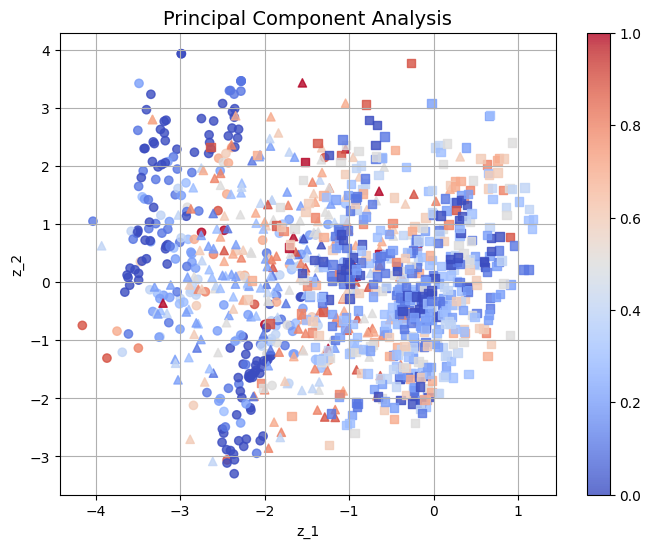

In [54]:
import matplotlib.pyplot as plt

marker_map = {0: 'o', 1: '^', 2: 's'}
plt.figure(figsize=(8, 6))

for target in range(3):
    subset = pca_df[pca_df["target"] == target]
    scatter = plt.scatter(subset["z_1"], subset["z_2"], 
                label=target, 
                marker=marker_map[target],
                c=subset["kDN"],
                cmap='coolwarm',
                alpha=0.8)

plt.colorbar(scatter)

plt.title("Principal Component Analysis", fontsize=14)
plt.xlabel("z_1")
plt.ylabel("z_2")

plt.grid()
plt.show()

As expected, we can see that there are a lot of instances with a medium kDN (on the light-red, light-blue range). As it was explained previously, when we are considering obesity, the difference between a normal weight and an overweight person is not as clear-cut as in other classification tasks, which will lead to a lot of instances being in the boundary between classes.

### Instance Space Analysis

Now, we'll do an alternative embedding method provided by the package in study known as **Instance Space Analysis (ISA)**.

For that, we just need to execute the following steps present in the [pyhard start website](https://ita-ml.gitlab.io/pyhard/start.html).

Remember to be in the pyhard environment created in the prerequisites:
    
```bash
conda activate pyhard-tutorial
```

Since for **IAS** we must use a dataset with only numerical features (and the original dataset isn't like that), we will export the dataset `df` to a `.csv` file.

```python
df.to_csv('pyhard-obesity.csv', index=False)
```

The steps to enable **ISA** have been already executed previously, and the results are presented in the folder `instance_space_analysis` in the repository.

Therefore, the only thing left to do is to run `pyhard app` command in that directory and explore the results.

![ISA](pyhard_ui.png)

## Analysis of the dataset for SVM, KNN, and Decision Trees

In [55]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize models
svm = SVC()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()

# Perform 10-fold cross-validation and calculate accuracy
svm_scores = cross_val_score(svm, X_scaled, y, cv=10, scoring='accuracy')
knn_scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
dt_scores = cross_val_score(dt, X_scaled, y, cv=10, scoring='accuracy')

# Print the mean accuracy for each model
print(f"SVM Accuracy: {svm_scores.mean():.4f}")
print(f"KNN Accuracy: {knn_scores.mean():.4f}")
print(f"Decision Tree Accuracy: {dt_scores.mean():.4f}")

SVM Accuracy: 0.9285
KNN Accuracy: 0.8248
Decision Tree Accuracy: 0.9825


### Only BMI

In [56]:
# Separate features and target
X = df[["BMI"]]

X_scaled = scaler.fit_transform(X)

# Perform 10-fold cross-validation and calculate accuracy
svm_scores = cross_val_score(svm, X_scaled, y, cv=10, scoring='accuracy')
knn_scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
dt_scores = cross_val_score(dt, X_scaled, y, cv=10, scoring='accuracy')

# Print the mean accuracy for each model
print(f"SVM Accuracy: {svm_scores.mean():.4f}")
print(f"KNN Accuracy: {knn_scores.mean():.4f}")
print(f"Decision Tree Accuracy: {dt_scores.mean():.4f}")

SVM Accuracy: 0.9607
KNN Accuracy: 0.9692
Decision Tree Accuracy: 0.9578


### Without BMI

In [57]:
# Separate features and target
X = df[[col for col in df.columns if col != 'BMI']].iloc[:, :-1]

X_scaled = scaler.fit_transform(X)

# Perform 10-fold cross-validation and calculate accuracy
svm_scores = cross_val_score(svm, X_scaled, y, cv=10, scoring='accuracy')
knn_scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
dt_scores = cross_val_score(dt, X_scaled, y, cv=10, scoring='accuracy')

# Print the mean accuracy for each model
print(f"SVM Accuracy: {svm_scores.mean():.4f}")
print(f"KNN Accuracy: {knn_scores.mean():.4f}")
print(f"Decision Tree Accuracy: {dt_scores.mean():.4f}")

SVM Accuracy: 0.7429
KNN Accuracy: 0.7552
Decision Tree Accuracy: 0.7458
